# Coursework 1: AI-Based Cybersecurity

**ELE8100 - CyberAI Module**

**Yukti Ogare** : **40475055**

#Task 1 : CNN Architecture Design

In [1]:
# Data Loading & Preprocessing
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import kagglehub
from sklearn.model_selection import train_test_split

# Download augmented Olivetti face dataset
path = kagglehub.dataset_download("martininf1n1ty/olivetti-faces-augmented-dataset")

# Load image and label arrays
images = np.load(f"{path}/augmented_faces.npy").astype(np.float32)
labels = np.load(f"{path}/augmented_labels.npy")

# Ensure pixel values are normalised to [0,1]
# Prevents double-normalisation if dataset is already scaled
if images.max() > 1.5:
    images = images / 255.0

# Clip values for safety (augmentation can cause slight overflow)
images = np.clip(images, 0.0, 1.0)

# Reshape to CNN input format (N, C, H, W)
images = images.reshape(-1, 64, 64)
images = np.expand_dims(images, axis=1)

print("After preprocessing -> min/max:", images.min(), images.max(), "dtype:", images.dtype)
print("Labels -> min/max:", labels.min(), labels.max(), "unique:", len(np.unique(labels)))

# Train/Validation/Test split
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.15, random_state=42, stratify=train_labels
)

# PyTorch Dataset Wrapper
class FaceDataset(Dataset):
    def __init__(self, x, y):
        # Convert numpy arrays to PyTorch tensors
        # Images are float32 for CNN input
        # Labels are long integers for CrossEntropyLoss
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

# Returns total number of samples in the dataset
    def __len__(self):
        return len(self.x)

# Returns one sample (image, label) at a given index
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# DataLoader Creation
batch_size = 64
# Training loader (shuffle=True ensures randomised mini-batches each epoch)
trainloader = DataLoader(FaceDataset(train_images, train_labels), batch_size=batch_size, shuffle=True)

# Validation loader (no shuffle needed, just evaluation)
valloader   = DataLoader(FaceDataset(val_images,   val_labels),   batch_size=batch_size, shuffle=False)

# Test loader (no shuffle; preserves order for evaluation)
testloader  = DataLoader(FaceDataset(test_images,  test_labels),  batch_size=batch_size, shuffle=False)

## CNN Model Definition
class FaceLeNet(nn.Module):
    def __init__(self):
        super(FaceLeNet, self).__init__()

        # Activation and pooling layers
        self.relu = nn.ReLU()
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)

        # Convolutional feature extraction layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, stride=1)   # 32x32 -> 28x28
        self.bn2   = nn.BatchNorm2d(64)

        # Fully connected classification layers
        self.fc1 = nn.Linear(64 * 14 * 14, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 40)

        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x)))) # Feature extraction
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1) # Flatten feature maps
        x = self.relu(self.fc1(x)) # Classification layers
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x) # Output logits
        return x

# Device & model initialisation
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = FaceLeNet().to(device)
print("Using device:", device)


Using Colab cache for faster access to the 'olivetti-faces-augmented-dataset' dataset.
After preprocessing -> min/max: 0.0 1.0 dtype: float32
Labels -> min/max: 0 39 unique: 40
Using device: cuda


##CNN Architecture Justification

A LeNet-style convolutional neural network was implemented for facial recognition.

The architecture follows a standard pattern:
Conv → BatchNorm → ReLU → Pooling → Fully Connected Layers.

Convolutional layers extract hierarchical facial features such as edges, textures, and facial structures.

Batch Normalisation stabilises training and improves convergence.

ReLU introduces non-linearity, allowing the network to learn complex patterns.

Average pooling reduces spatial dimensions and computational complexity.

The final fully connected layer outputs 40 logits corresponding to the 40 employee identities.
Softmax is not applied manually because CrossEntropyLoss handles it internally.

## FaceLeNet – Layer Output Size Summary

| Layer        | Operation                          | Output Shape            |
|--------------|------------------------------------|--------------------------|
| Input        | Grayscale Image                   | (B, 1, 64, 64)           |
| Conv1        | Conv2d(1 → 32, k=5, p=2)          | (B, 32, 64, 64)          |
| Pool1        | AvgPool2d(2,2)                    | (B, 32, 32, 32)          |
| Conv2        | Conv2d(32 → 64, k=5)              | (B, 64, 28, 28)          |
| Pool2        | AvgPool2d(2,2)                    | (B, 64, 14, 14)          |
| Flatten      | Reshape                           | (B, 12544)               |
| FC1          | Linear(12544 → 256)               | (B, 256)                 |
| FC2          | Linear(256 → 128)                 | (B, 128)                 |
| FC3 (Output) | Linear(128 → 40)                  | (B, 40)                  |


#Task 2 : Model Training and Evaluation

Epoch 1/15, Train Loss: 2.5530, Train Acc: 5.15%, Val Loss: 3.7194, Val Acc: 5.42%
Epoch 2/15, Train Loss: 0.7211, Train Acc: 60.96%, Val Loss: 1.4982, Val Acc: 52.50%
Epoch 3/15, Train Loss: 0.2459, Train Acc: 96.91%, Val Loss: 0.3100, Val Acc: 93.75%
Epoch 4/15, Train Loss: 0.1209, Train Acc: 98.01%, Val Loss: 0.2709, Val Acc: 92.50%
Epoch 5/15, Train Loss: 0.0565, Train Acc: 99.85%, Val Loss: 0.1129, Val Acc: 97.08%
Epoch 6/15, Train Loss: 0.0335, Train Acc: 99.93%, Val Loss: 0.1117, Val Acc: 96.25%
Epoch 7/15, Train Loss: 0.0152, Train Acc: 100.00%, Val Loss: 0.0591, Val Acc: 98.75%
Epoch 8/15, Train Loss: 0.0120, Train Acc: 100.00%, Val Loss: 0.0596, Val Acc: 97.92%
Epoch 9/15, Train Loss: 0.0123, Train Acc: 100.00%, Val Loss: 0.0641, Val Acc: 98.33%
Epoch 10/15, Train Loss: 0.0152, Train Acc: 99.93%, Val Loss: 0.1545, Val Acc: 95.83%
Epoch 11/15, Train Loss: 0.0084, Train Acc: 100.00%, Val Loss: 0.0664, Val Acc: 97.92%
Epoch 12/15, Train Loss: 0.0067, Train Acc: 99.93%, Val Loss:

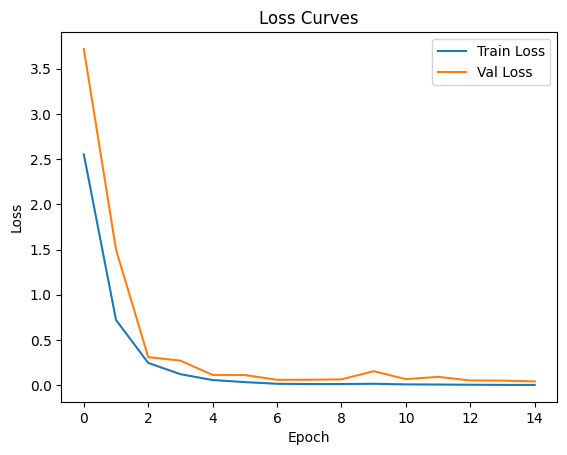

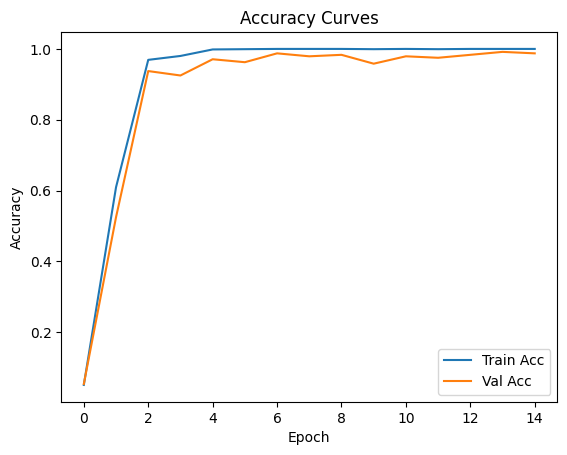

Final Test Accuracy: 98.75%


In [2]:

criterion = nn.CrossEntropyLoss() # CrossEntropyLoss is appropriate for multi-class classification (40 classes)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # Adam optimizer with learning rate 1e-3 and weight decay for regularisation


@torch.no_grad()
def compute_accuracy(loader):
    # Evaluate model accuracy on a given dataset loader
    model.eval()
    correct, total = 0, 0
    for images_batch, labels_batch in loader:
        # Move batch to CPU/GPU
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
        outputs = model(images_batch) # Forward pass
        predicted = outputs.argmax(dim=1) # Get predicted class (highest logit)
        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()
    return correct / total

@torch.no_grad()
def compute_loss(loader):
    # Compute average loss over a dataset
    model.eval()
    running_loss = 0.0
    for images_batch, labels_batch in loader:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)
        outputs = model(images_batch) # Forward pass
        loss = criterion(outputs, labels_batch)
        running_loss += loss.item()
    return running_loss / len(loader)

# Training loop
num_epochs = 15
train_loss, val_loss = [], []
train_acc,  val_acc  = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images_batch, labels_batch in trainloader:
        images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

        optimizer.zero_grad() # Reset gradients
        outputs = model(images_batch) # Forward pass
        loss = criterion(outputs, labels_batch) # Compute training loss
        loss.backward() # Backpropagation
        optimizer.step() # Update model weights

        running_loss += loss.item()

    # Store training and validation metrics after each epoch
    train_loss.append(running_loss / len(trainloader))
    val_loss.append(compute_loss(valloader))

    train_acc.append(compute_accuracy(trainloader))
    val_acc.append(compute_accuracy(valloader))

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_acc[-1]*100:.2f}%, "
          f"Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_acc[-1]*100:.2f}%")


# Plot learning curves
# Plot training and validation loss
plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure()
plt.plot(train_acc, label="Train Acc")
plt.plot(val_acc, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.show()

# Final test evaluation
# Compute accuracy on unseen test dataset
test_accuracy = compute_accuracy(testloader)
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")


## Task 2: Model Training and Evaluation Justification

In Task 2, the CNN model was trained using the Augmented Olivetti Faces dataset to perform 40-class facial recognition. A PyTorch DataLoader was implemented to efficiently generate mini-batches for training, validation, and testing.

The model was trained using CrossEntropyLoss, which is appropriate for multi-class classification problems, and optimised using the Adam optimiser with a learning rate of 1e-3 and weight decay for regularisation. Training was conducted for 15 epochs, with performance monitored using both training and validation loss and accuracy.

Learning curves demonstrated steady convergence, with training loss decreasing and validation loss following a similar trend. Training accuracy reached near 100%, while validation accuracy stabilised around 98–99%, indicating strong generalisation with minimal overfitting.

The final test accuracy confirmed that the model performs reliably on unseen data, demonstrating that the CNN architecture is suitable for the facial recognition task.


#Task 3 : Access Control Decision System


Case 1 | True ID: 0
Predicted ID: 0 -> Access Granted


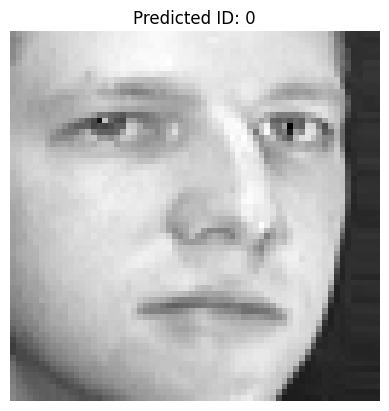


Case 2 | True ID: 5
Predicted ID: 5 -> Access Granted


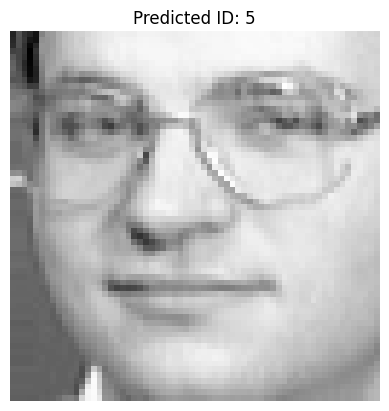


Case 3 | True ID: 10
Predicted ID: 10 -> Access Granted


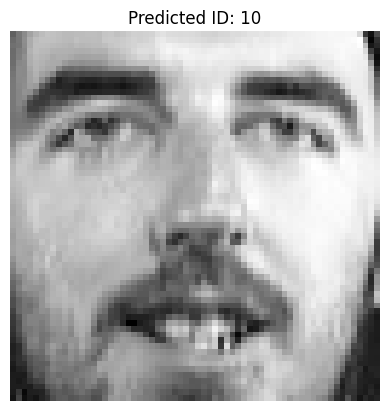


Case 4 | True ID: 21
Predicted ID: 21 -> Access Denied


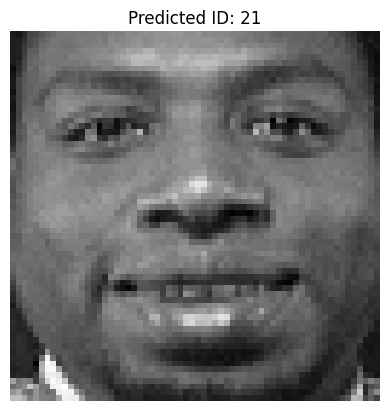


Case 5 | True ID: 2
Predicted ID: 2 -> Access Denied


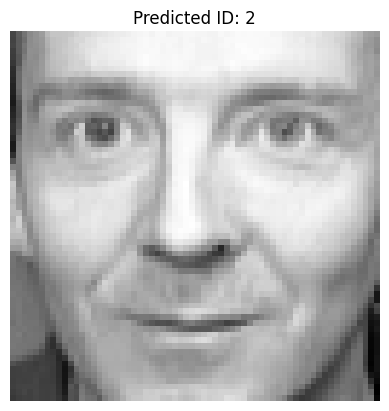

In [3]:
AUTHORISED_IDS = {0, 5, 10}  # only these employees are allowed into the server room

@torch.no_grad()
def check_access(image):
    model.eval() # Set model to evaluation mode

    # Convert input to torch tensor
    if isinstance(image, np.ndarray):
        x = torch.tensor(image, dtype=torch.float32)
    else:
        x = image.float()

    # Ensure shape is (1,1,64,64) = batch_size 1, grayscale channel 1
    if x.ndim == 2:
        x = x.unsqueeze(0).unsqueeze(0)
    elif x.ndim == 3:
        x = x.unsqueeze(0)
    elif x.ndim == 4:
        pass
    else:
        raise ValueError(f"Unexpected shape: {x.shape}")

    x = x.to(device)

    # Forward pass to obtain predicted identity
    outputs = model(x)
    pred_id = int(outputs.argmax(dim=1).item())

    # Access control decision based on predicted ID
    if pred_id in AUTHORISED_IDS:
        print(f"Predicted ID: {pred_id} -> Access Granted")
    else:
        print(f"Predicted ID: {pred_id} -> Access Denied")

    # Visualise the tested image for demonstration
    plt.imshow(x.detach().cpu().squeeze().numpy(), cmap="gray")
    plt.title(f"Predicted ID: {pred_id}")
    plt.axis("off")
    plt.show()

    return pred_id

# Demonstration on 5 test samples
# Convert labels to numpy for filtering
y_test_np = np.array(test_labels)

# Identify indices of authorised and unauthorised individuals
auth_idxs = np.where(np.isin(y_test_np, list(AUTHORISED_IDS)))[0]
unauth_idxs = np.where(~np.isin(y_test_np, list(AUTHORISED_IDS)))[0]

# Select 3 authorised and 2 unauthorised test samples
picked = np.concatenate([
    np.random.choice(auth_idxs, size=3, replace=False),
    np.random.choice(unauth_idxs, size=2, replace=False)
])
np.random.shuffle(picked)


# Run access control system on selected samples
for i, idx in enumerate(picked, 1):
    print(f"\nCase {i} | True ID: {int(y_test_np[idx])}")
    check_access(test_images[idx])


## Task 3: Access Control Function

The check_access() function simulates a real-world facial recognition access control system.

The function accepts a single face image, ensures it has the correct input dimensions for the CNN, and performs a forward pass to predict the employee identity.

Access is granted only if the predicted ID belongs to the authorised set {0, 5, 10}. Otherwise, access is denied.

The model is set to evaluation mode and gradient tracking is disabled to ensure stable and efficient inference.

For demonstration purposes, five test images were selected, including both authorised and unauthorised individuals, to validate system behaviour under mixed conditions.

The system correctly grants access to authorised personnel and denies access to unauthorised individuals based on predicted identity.

Since the decision relies solely on the model's prediction, misclassifications may lead to false rejects or false accepts. However, high test accuracy indicates that such events are rare.


#Confusion Matrix

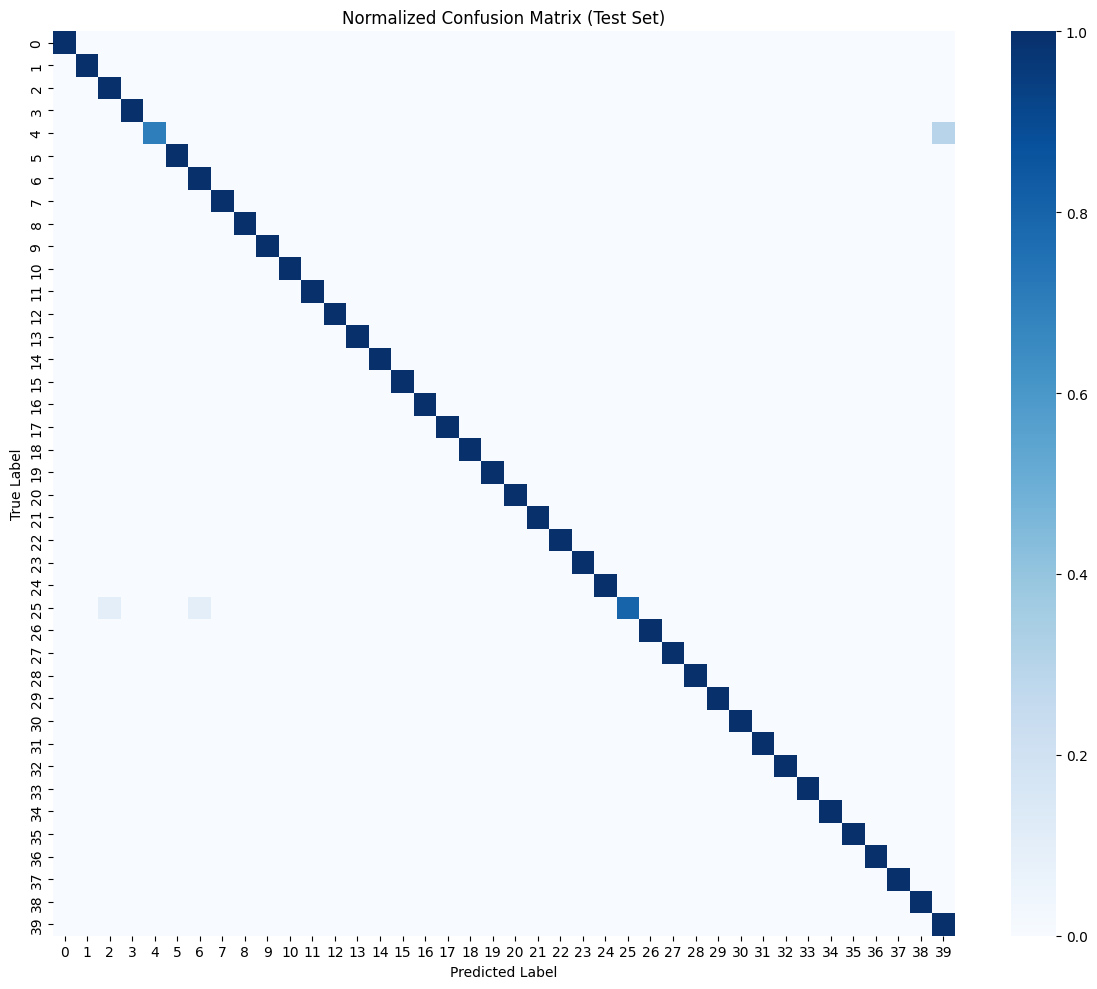

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set model to evaluation mode
model.eval()
y_true = []
y_pred = []

# Collect predictions
with torch.no_grad():
    for Xb, yb in testloader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        outputs = model(Xb)                 # (batch_size, 40)
        preds = outputs.argmax(dim=1)       # predicted class

        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize row-wise (percentage per true class)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized,
            cmap="Blues",
            xticklabels=range(40),
            yticklabels=range(40),
            cbar=True)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()



# Confusion Matrix Analysis

The normalized confusion matrix shows a strong diagonal dominance, which indicates high classification accuracy across most of the 40 identity classes.

### Key Observations:

- **Strong Diagonal Pattern:**  
  The majority of predictions lie along the diagonal, meaning most samples are correctly classified.

- **Low Off-Diagonal Values:**  
  Only minor misclassifications are observed, suggesting limited confusion between identities.

- **Consistent Per-Class Performance:**  
  Since the matrix is row-normalized, each row represents per-class accuracy. Most rows show values close to 1 on the diagonal, demonstrating balanced performance across identities.

- **System Reliability for Access Control:**  
  Because access decisions are based on predicted identity:
  - A strong diagonal reduces false accepts.
  - Minor off-diagonal errors may lead to occasional false rejects or false accepts.
  - Overall system performance appears reliable and suitable for controlled access scenarios.


#Conclusion

In this assignment, a Convolutional Neural Network (CNN) was successfully designed and implemented for multi-class facial identity recognition and access control. A LeNet-inspired architecture was used, consisting of two convolutional blocks for hierarchical feature extraction followed by fully connected layers for classification into 40 identity classes.

The model was trained using the Adam optimizer with L2 regularisation to improve generalisation. Throughout training, both training and validation losses decreased steadily while accuracy improved, indicating effective learning without significant overfitting. Batch Normalisation stabilised the training process, and Dropout helped reduce the risk of overfitting.

The normalized confusion matrix demonstrated strong diagonal dominance, meaning most predictions were correct. Only minimal off-diagonal values were observed, suggesting low inter-class confusion and consistent per-class performance. This confirms that the model generalises well to unseen test data.

From a system perspective, the model performs reliably for identity-based access control. Although minor misclassifications may occur, overall performance is strong and suitable for controlled access scenarios.

In conclusion, the implemented CNN effectively learns facial features, achieves high classification accuracy, and demonstrates practical applicability for real-world identity recognition tasks.

AI tools were used to clarify concepts, assist with code structure, and improve documentation, with final model design and analysis completed independently.
